# Predicting the NCAA Men's Gymnastics Team Champion

**Can you tell who is going to win the national title before the national meet happens?**

Every NCAA men's gymnastics season ends with one team holding the trophy. This project aims to see
if we can predict that outcome from regular-season data alone. And if so, at what point in the
season can we start to form a realistic prediction.

The dataset is every NCAA team-season from 2013 through 2025 (2020 was cancelled by COVID-19),
scraped from the [Road to Nationals](https://www.roadtonationals.com) API. Each team-season is
described by per-apparatus scoring features, and labeled `champion = 1` or `0`. The 2026 season
is then used as a genuine forward test: the prediction was made from pre-championship data,
before the meet occurred.

### The Results

1. **The obvious approach doesn't work.** Picking the team with the highest average total score
   identifies the champion in only **7 of 12** seasons.
2. **One feature is more predictive than any model, though the model is how we found it.**
   A team's NQA (National Qualifying Average) on **parallel bars** identifies the champion in
   **12 of 12** labeled seasons, and again in 2026 for **13 of 13**. That's a single number, not
   a model, and it's the only feature we found that lined up with the winner every time. It came
   out of the regression: parallel bars kept coming back as the heaviest weight, which is what
   prompted testing it on its own.
3. **The trained model gets close, but I wouldn't bet money on it.** A regularized logistic
   regression on 27 features gets both held-out seasons right (2024, 2025). On the 2026 forward
   test, different versions kept flipping between Stanford and Oklahoma for the top spot, and the
   final margins were too tight to call it either way. Both versions did get the top four right,
   though that may say more about the sport than the model, since the same four or five programs
   dominate season after season.

---

## 0. Environment

The notebook caches its fetched data so the API only has to be hit once. On Colab that cache lives
in Drive; locally it is just a file on disk.

In [1]:
# Colab only. Mounts Drive so fetched data survives between sessions.
# Running locally? Skip this cell. CACHE_PATH below falls back to a local file.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Colab, caching to a local file.")

Mounted at /content/drive


## 1. Setup and Data Source

All data comes from the Road to Nationals (RTN) men's gymnastics API. Two endpoints matter:

| Endpoint | What it gives us |
|---|---|
| `dashboard/{year}/{team_id}` | Team metadata, conference ID, and the **official total score** for each meet |
| `teamconsistency/{year}/{team_id}` | Dated **per-apparatus scores** (floor, pommel, rings, vault, p-bars, high bar) |

We need both. `teamconsistency` is the only source of apparatus-level detail, but `dashboard`
carries the officially recognized team total, and as Section 3 shows, those two do not always
agree. Reconciling them is the first real task.

A conference filter restricts us to NCAA programs. RTN also tracks GymACT teams (the club circuit
several programs moved to after their varsity teams were cut), and mixing those in would corrupt
both the labels and the scoring distributions.

In [2]:
import requests
import pandas as pd
import numpy as np
import pickle
import os
from datetime import datetime

BASE_URL   = "https://www.roadtonationals.com/api/men"
CACHE_PATH = ('/content/drive/MyDrive/ncaa_gymnastics/raw_data.pkl' if IN_COLAB
              else 'ncaa_raw_data.pkl')

# 2020 is absent: the season was cancelled by COVID-19 before the championship.
SEASONS      = [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]

# Big Ten, ECAC, MPSF. Anything else is GymACT or unaffiliated.
NCAA_CONFS   = {'1', '2', '4'}

# Discovered by scanning the ID space, see Section 2.
ALL_TEAM_IDS = [1, 2, 3, 6, 12, 13, 20, 22, 23, 24, 28,
                29, 30, 38, 39, 42, 46, 50, 51, 64, 65]

# RTN returns 403 without these.
HEADERS = {
    'User-Agent': ('Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 '
                   '(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'),
    'Referer': 'https://www.roadtonationals.com/'
}

print(f"{len(SEASONS)} seasons, {len(ALL_TEAM_IDS)} candidate team IDs")
print(f"Cache path: {CACHE_PATH}")

12 seasons, 21 candidate team IDs
Cache path: /content/drive/MyDrive/ncaa_gymnastics/raw_data.pkl


### Optional: load from cache

If the data has already been fetched, this cell restores everything and the fetching cells in
Sections 4-5 can be skipped. On a cold run, skip this cell and let the notebook rebuild from the API.

In [3]:
# Optional fast path
# Restores: raw_data, champions, df, df_norm
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'rb') as f:
        saved = pickle.load(f)
    raw_data  = saved['raw_data']
    champions = saved['champions']
    df        = saved['df']
    df_norm   = saved['df_norm']
    print(f"Loaded {len(raw_data)} team-seasons | df {df.shape} | df_norm {df_norm.shape}")
else:
    print("No cache found. Run the fetch cells in Sections 4 and 5.")

Loaded 184 team-seasons | df (184, 32) | df_norm (184, 32)


## 2. Which Teams Count?

`ALL_TEAM_IDS` above was not guessed. RTN assigns each program a numeric ID with no public
directory, so the roster was found by scanning the ID space and keeping every team whose
`conference_id` marked it as NCAA.

Men's gymnastics is a small sport. The scan turns up roughly 15 to 17 varsity programs per season,
which is why the champion class is so rare (12 champions in 185 team-seasons, about 6.5%). That
class imbalance drives several modeling decisions later.

In [5]:
# Roster discovery: scan the ID space for NCAA programs
# Run once to regenerate ALL_TEAM_IDS. 2013 is used as the reference season
# because it is the earliest in the study window.
def discover_teams(year, id_range=range(1, 120)):
    found = []
    for team_id in id_range:
        try:
            dash = requests.get(f"{BASE_URL}/dashboard/{year}/{team_id}",
                                headers=HEADERS, timeout=30).json()
            ty   = dash.get('ty_info')
            conf = str(ty.get('conference_id', '')) if isinstance(ty, dict) else ''
            if conf in NCAA_CONFS:
                found.append({'team_id': team_id,
                              'team_name': dash['info']['team_name'],
                              'conf': conf})
        except Exception:
            pass
    return found

teams_2013 = discover_teams(2013)
for t in teams_2013:
    print(f"  ID {t['team_id']:>3}: {t['team_name']:<22} (conf {t['conf']})")
print(f"\nFound {len(teams_2013)} NCAA teams in 2013")

  ID   1: Air Force              (conf 4)
  ID   3: Army                   (conf 2)
  ID   6: California             (conf 4)
  ID  12: Illinois               (conf 1)
  ID  13: Iowa                   (conf 1)
  ID  20: Michigan               (conf 1)
  ID  22: Minnesota              (conf 1)
  ID  23: Navy                   (conf 2)
  ID  24: Nebraska               (conf 1)
  ID  28: Ohio State             (conf 1)
  ID  29: Oklahoma               (conf 4)
  ID  30: Penn State             (conf 1)
  ID  38: Springfield College    (conf 2)
  ID  39: Stanford               (conf 4)
  ID  42: Temple                 (conf 2)
  ID  46: UIC                    (conf 2)
  ID  51: William & Mary         (conf 2)

Found 17 NCAA teams in 2013


## 3. Is the Data Trustworthy?

Before modeling anything, the two endpoints need to be reconciled.

`teamconsistency` gives six apparatus scores per meet. `dashboard` gives one official team total
per meet. In principle the six apparatus scores should sum to the team total. Where they don't,
either the scrape is misaligned or the underlying data is wrong, and either way, features built on
top of it would be garbage.

The check below computes `delta = |sum(apparatus) - dashboard_total|` for every meet and flags
anything above a small tolerance.

In [7]:
# Integrity check helper
def check_team_season(year, team_id):
    '''Compare summed apparatus scores against the official dashboard total.'''
    dash = requests.get(f"{BASE_URL}/dashboard/{year}/{team_id}",
                        headers=HEADERS, timeout=30).json()
    cons = requests.get(f"{BASE_URL}/teamconsistency/{year}/{team_id}",
                        headers=HEADERS, timeout=30).json()

    # Dashboard → keep only meets that have an official score
    dash_rows = []
    for m in dash['meets']:
        if m['team_score'] is not None:
            dash_rows.append({
                'date_raw' : m['meet_date'],
                'dashboard': float(m['team_score']),
            })

    # teamconsistency → sum the six apparatus per meet
    apps = ['fxs', 'phs', 'srs', 'vts', 'pbs', 'hbs']
    cons_rows = []
    for i, label in enumerate(cons['labels']):
        cons_rows.append({
            'label'    : label,
            'apparatus': sum(float(cons[a][i]) for a in apps),
        })

    # Align on date. Dashboard dates look like "Sat, Jan-18-2025";
    # teamconsistency dates look like "Jan-18-25".
    for r in dash_rows:
        r['key'] = r['date_raw'].split(', ')[-1].replace('-20', '-')
    for r in cons_rows:
        r['key'] = r['label']

    merged = pd.merge(pd.DataFrame(dash_rows), pd.DataFrame(cons_rows), on='key', how='inner')
    merged['delta'] = (merged['apparatus'] - merged['dashboard']).abs().round(3)
    return merged[['key', 'dashboard', 'apparatus', 'delta']]

### A known-bad example

Illinois 2025 contains a meet whose displayed total is known to be wrong (side note: I found this meet completely by accident, which is what prompted the whole dataset check). If the check is working,
it should surface as a non-zero delta.

In [8]:
il_2025 = check_team_season(2025, 12)
print(il_2025.to_string(index=False))

      key  dashboard  apparatus  delta
Jan-18-25    319.700    321.700    2.0
Jan-25-25    325.500    325.500    0.0
Jan-31-25    321.300    321.300    0.0
Feb-08-25    315.450    315.450    0.0
Mar-01-25    316.700    316.700    0.0
Mar-08-25    312.550    312.550    0.0
Mar-25-25    322.450    322.450    0.0
Apr-04-25    320.950    320.950    0.0
Apr-18-25    323.194    323.194    0.0
Apr-19-25    316.293    316.293    0.0


### First pass: check every NCAA team-season

Now the same check across every NCAA season and team in the study window, with no conference
filter, so we can see the raw flag rate before we exclude anything. The filtered pass below runs on
exactly the same seasons and teams, so any difference between the two comes from the filter alone.

In [11]:
# First pass: no conference filter
# Same seasons and teams as the filtered pass below, so the only thing that
# differs between the two is the filter itself.
all_deltas = []
for year in SEASONS:
    print(f"Checking {year}...", end=" ")
    for team_id in ALL_TEAM_IDS:
        try:
            chk = check_team_season(year, team_id)
            chk['year'], chk['team_id'] = year, team_id
            all_deltas.append(chk)
        except Exception:
            pass          # program not active that season, or endpoint missing
    print("done")

deltas_raw = pd.concat(all_deltas, ignore_index=True)
flagged    = deltas_raw[deltas_raw['delta'] > 0.05]
print(f"\nTotal meets checked : {len(deltas_raw)}")
print(f"Flagged (delta>0.05): {len(flagged)}  ({len(flagged)/len(deltas_raw):.1%})")

Checking 2013... done
Checking 2014... done
Checking 2015... done
Checking 2016... done
Checking 2017... done
Checking 2018... done
Checking 2019... done
Checking 2021... done
Checking 2022... done
Checking 2023... done
Checking 2024... done
Checking 2025... done

Total meets checked : 1998
Flagged (delta>0.05): 93  (4.7%)


### What the flags were


The first pass flagged **102 of 1,539 meets (6.6%)**. Investigating them
turned up two causes:

*The counts in this section come from a run in spring 2026. Road to Nationals is a live database
and its historical records get corrected over time, so a later pass may check more meets and flag a
slightly different number.*

**1. GymACT contamination.** Several programs (Arizona State, Iowa, Minnesota, Temple) were cut as
varsity teams and kept competing in GymACT. RTN still tracks them under the same team ID, but their
`teamconsistency` records in those seasons don't line up with the dashboard totals, which is where
the 60-75 point deltas come from. Nothing is being scored wrong here. We were comparing two things
that were never meant to match. Those seasons aren't NCAA competition and don't belong in the
dataset at all.

**2. Legitimate team neutral deductions.** A cluster of exactly-1.0 deltas turned out to be real.
Neutral deductions (athlete replacement, equipment violations, attire) are applied to the team
total *after* apparatus scoring. The `dashboard` value correctly reflects the penalized final
score; `teamconsistency` shows the raw apparatus sum. Both numbers are right, they just measure
different things.

The fix is to filter on `conference_id` so only genuine NCAA team-seasons are compared.

In [10]:
# Second pass: NCAA conferences only
clean_deltas, skipped = [], 0

for year in SEASONS:
    print(f"Checking {year}...", end=" ")
    for team_id in ALL_TEAM_IDS:
        try:
            dash = requests.get(f"{BASE_URL}/dashboard/{year}/{team_id}",
                                headers=HEADERS, timeout=30).json()
            ty   = dash.get('ty_info')
            conf = str(ty.get('conference_id', '')) if isinstance(ty, dict) else ''

            if conf not in NCAA_CONFS:      # GymACT or unaffiliated, not comparable
                skipped += 1
                continue

            chk = check_team_season(year, team_id)
            chk['year']      = year
            chk['team_id']   = team_id
            chk['team_name'] = dash['info']['team_name']
            clean_deltas.append(chk)
        except Exception:
            pass
    print("done")

deltas = pd.concat(clean_deltas, ignore_index=True)
flagged_clean = deltas[deltas['delta'] > 0.05]

print(f"\nSkipped (non-NCAA)  : {skipped} team-seasons")
print(f"Total meets checked : {len(deltas)}")
print(f"Flagged (delta>0.05): {len(flagged_clean)}  ({len(flagged_clean)/len(deltas):.1%})")
print("\nFlagged rows by delta value:")
print(flagged_clean['delta'].value_counts().to_string())

Checking 2013... done
Checking 2014... done
Checking 2015... done
Checking 2016... done
Checking 2017... done
Checking 2018... done
Checking 2019... done
Checking 2021... done
Checking 2022... done
Checking 2023... done
Checking 2024... done
Checking 2025... done

Skipped (non-NCAA)  : 37 team-seasons
Total meets checked : 1880
Flagged (delta>0.05): 25  (1.3%)

Flagged rows by delta value:
delta
1.0    21
2.0     3
0.1     1


### Integrity conclusion

Filtering to NCAA-only team-seasons dropped the flag rate from **6.6% (102/1,539)** to
**1.6% (22/1,415)**. Of the 22 that remain:

- **20 rows with delta = 1.0**: team neutral deductions. Penalties for things like athlete
  replacement or equipment violations are applied to the team total after apparatus scoring, so
  the dashboard shows the penalized score while `teamconsistency` shows the raw sum. Both are
  right, they're just measuring different things.
- **1 row with delta = 2.0**: Greenville (Feb-01-2025). Probably a double deduction, and possibly
  related to the non-regulation vault landing mats at their home venue, but we couldn't confirm
  that.
- **1 row with delta = 2.0**: Illinois (Jan-18-2025). We never figured this one out. The dashboard
  reports 319.700 while the apparatus scores sum to 321.700, and we found nothing that accounts
  for the gap.

**Verdict: good enough to build on.** Our features come from per-apparatus scores, not team
totals, so the 20 neutral-deduction rows never touch them. Illinois is the one exception we can't
rule out, and it's one meet out of 1,415. The conference filter we built here gets reused for the
real data pull.

## 4. Ground Truth: Who Actually Won

The label. `finalresults/{year}` returns the final NCAA Championship standings; the top row is the
champion. This is the target variable: `champion = 1` for the winning team-season, `0` for everyone
else.

Two things worth noticing in the output:

- **Only three programs win.** Michigan, Oklahoma, and Stanford account for every title from 2013
  to 2026. Any model has to deal with that concentration, and it makes the "just pick one of
  those teams" baseline hard to beat.
- **Score levels are not comparable across seasons.** Champions score ~443 in 2013 and ~332 in
  2025. This is due to rule changes, and Section 7 deals with it.

In [12]:
# Fetch champions for every labeled season
champions = {}
for year in SEASONS:
    try:
        data = requests.get(f"{BASE_URL}/finalresults/{year}",
                            headers=HEADERS, timeout=30).json()
        if data.get('data'):
            champ = data['data'][0]
            champions[year] = {
                'team_id'    : int(champ['team_id']),
                'team_name'  : champ['team_name'],
                'final_score': float(champ['ncaa_final']),
            }
            print(f"{year}: {champ['team_name']:<12} ({champ['ncaa_final']})")
    except Exception:
        print(f"{year}: no results available")

print(f"\n{len(champions)} labeled seasons")
print(f"Distinct champions: {sorted({c['team_name'] for c in champions.values()})}")

2013: Michigan     (443.2)
2014: Michigan     (445.05)
2015: Oklahoma     (447.05)
2016: Oklahoma     (443.4)
2017: Oklahoma     (431.95)
2018: Oklahoma     (414.858)
2019: Stanford     (415.222)
2021: Stanford     (414.521)
2022: Stanford     (423.628)
2023: Stanford     (422.458)
2024: Stanford     (425.324)
2025: Michigan     (332.224)

12 labeled seasons
Distinct champions: ['Michigan', 'Oklahoma', 'Stanford']


## 5. Building the Dataset

One row per NCAA team-season. Each record keeps the dated per-apparatus scores (the raw material
for features), the official meet totals, and the champion label.

The conference filter from Section 3 is applied here, so GymACT seasons never enter the dataset.

In [13]:
# Fetch all raw data
raw_data = []
for year in SEASONS:
    print(f"Fetching {year}...", end=" ")
    count = 0
    for team_id in ALL_TEAM_IDS:
        try:
            dash = requests.get(f"{BASE_URL}/dashboard/{year}/{team_id}",
                                headers=HEADERS, timeout=30).json()
            ty   = dash.get('ty_info')
            conf = str(ty.get('conference_id', '')) if isinstance(ty, dict) else ''
            if conf not in NCAA_CONFS:
                continue

            meet_scores = [float(m['team_score']) for m in dash['meets']
                           if m['team_score'] is not None]
            if not meet_scores:
                continue

            cons = requests.get(f"{BASE_URL}/teamconsistency/{year}/{team_id}",
                                headers=HEADERS, timeout=30).json()

            raw_data.append({
                'year'       : year,
                'team_id'    : team_id,
                'team_name'  : dash['info']['team_name'],
                'champion'   : int(champions.get(year, {}).get('team_id') == team_id),
                'meet_scores': meet_scores,
                'meet_dates' : cons['labels'],
                'apparatus'  : {a: [float(x) for x in cons[a]]
                                for a in ['fxs', 'phs', 'srs', 'vts', 'pbs', 'hbs']},
            })
            count += 1
        except Exception:
            pass
    print(f"{count} teams")

print(f"\nTotal team-seasons : {len(raw_data)}")
print(f"Champion entries   : {sum(r['champion'] for r in raw_data)}")

Fetching 2013... 17 teams
Fetching 2014... 15 teams
Fetching 2015... 15 teams
Fetching 2016... 16 teams
Fetching 2017... 16 teams
Fetching 2018... 16 teams
Fetching 2019... 16 teams
Fetching 2021... 15 teams
Fetching 2022... 13 teams
Fetching 2023... 15 teams
Fetching 2024... 15 teams
Fetching 2025... 15 teams

Total team-seasons : 184
Champion entries   : 12


## 6. Feature Engineering

An NCAA team score is the sum of six apparatus scores, and each apparatus score is the sum of the
routines in that team's lineup for that event. We pull per-apparatus scores from the
`teamconsistency` endpoint and use `finalresults` only for the champion labels.

Every feature is computed from meets on or before **April 8**, which falls between the conference
championships and the NCAA Championship, so nothing the model sees comes from the event it's
predicting.

### How the feature set evolved

We started with straightforward aggregates of regular-season data: per-apparatus mean, standard
deviation, maximum, and slope over the last few meets, plus season-level versions of the same.
That set is a reasonable description of a team and it's what the first models ran on.

NQA came later, and not from theory. It came out of the parallel bars investigation in Section 11,
after which we built it for all six apparatus and used it in place of the per-event means. Both
versions of the model are real results and they don't always agree, which comes up again in
Section 14.

### The features

**Apparatus maximum.** The highest score a team posted on each apparatus all season (6 features).
This is the team's demonstrated ceiling on the event.

**Apparatus standard deviation.** How scattered a team's scores are on each apparatus. A team that
posts similar numbers every week has a low standard deviation; a team with big highs and bad lows
has a high one. We compute this for all six apparatus, but drop `std_vt` before modeling for
reasons covered in Section 8.

**Apparatus score trajectory.** The slope of a linear fit over each team's last three to four
meets on that apparatus (6 features). A loose read on which direction a team is moving.

**Season aggregates.** Season-level versions of the same idea: total mean, total maximum, total
slope, and the number of valid meets (4 features). We include meet count but make no claim about
what it means. Some top teams compete less than weaker programs, and the weight the model puts on
it is small.

**Conference championship total.** The team's total score at their conference championship (1
feature). It's the last meet before nationals and every program treats it as the most important
one they've had all year, so it gets its own feature.

**NQA per apparatus.** The NCAA ranks teams with a National Qualifying Average: drop the highest
regular-season score on the apparatus, average the next three, then average that result with the
conference championship score on the same apparatus (6 features).

A plain season average is a poor summary of a gymnastics team. Scores are volatile, one bad meet
drags the mean down, and the sport itself doesn't rank teams that way. NQA drops the outlier peak
and pulls the conference result forward, which weights the part of the season when a team is
closest to the shape it'll be in at nationals.

Two practical notes. NQA can only be computed once the conference championship has happened, since
it needs that score to exist. And nothing in the API flags which meet was a team's conference
championship, so we infer it as the last meet on or before the cutoff. For the week-by-week
analysis in Section 15, which uses cutoffs throughout the regular season, we fall back to a simpler
average of a team's top four apparatus scores. That average was also the precursor to NQA in our
own feature engineering.

Swapping per-event means for per-event NQA is the change that mattered most. The parallel-bars
baseline goes from 10/12 to 12/12 on that alone (Section 11).

In [4]:
# Feature computation
def parse_meet_date(label, year):
    '''Convert a teamconsistency label like "Jan-18-25" to a datetime.'''
    try:
        return datetime.strptime(label, '%b-%d-%y')
    except Exception:
        return None


def compute_features(record, cutoff_month=4, cutoff_day=8, min_meets=2):
    '''
    Compute features for one team-season using only meets on or before the cutoff.

    Default cutoff is April 8, after the conference championships and before
    the NCAA Championship, so no feature can encode the outcome being predicted.
    '''
    apps  = ['fxs', 'phs', 'srs', 'vts', 'pbs', 'hbs']
    names = ['fx',  'ph',  'sr',  'vt',  'pb',  'hb']
    year  = record['year']

    # --- Restrict to meets before the cutoff ---
    cutoff = datetime(year, cutoff_month, cutoff_day)
    valid  = []
    for i, label in enumerate(record['meet_dates']):
        dt = parse_meet_date(label, year)
        if dt is not None and dt <= cutoff:
            valid.append(i)

    if len(valid) < min_meets:
        return None                      # too few meets to summarize

    feats = {}
    for app, name in zip(apps, names):
        all_scores = np.array(record['apparatus'][app])
        scores     = all_scores[valid]

        # NQA: drop the highest regular-season score, take the next three,
        # then average those against the conference championship score.
        conf_score = all_scores[valid[-1]]     # last meet before cutoff
        reg_scores = scores[:-1]               # everything except conference
        sorted_reg = np.sort(reg_scores)[::-1]
        top3_reg   = sorted_reg[1:4]           # drop the peak, keep next three
        feats[f'nqa_{name}'] = (np.sum(top3_reg) + conf_score) / 4

        feats[f'std_{name}'] = np.std(scores)
        feats[f'max_{name}'] = np.max(scores)

        last = scores[-4:]                     # late-season trajectory
        feats[f'slope_{name}'] = np.polyfit(range(len(last)), last, 1)[0]

    # Season totals summed from the apparatus scores rather than taken from the
    # dashboard. The dashboard lists individual-only meets with a team score of
    # 0.000, and it does not always hold the same meets as teamconsistency, so
    # indexing it by a teamconsistency count pulls in phantom zeros.
    per_meet_total = np.sum([np.array(record['apparatus'][a])[valid] for a in apps], axis=0)

    feats['mean_total']       = float(np.mean(per_meet_total))
    feats['max_total']        = float(np.max(per_meet_total))
    last4_total               = per_meet_total[-4:]
    feats['slope_total']      = float(np.polyfit(range(len(last4_total)), last4_total, 1)[0])
    feats['conf_champ_total'] = float(per_meet_total[-1])
    feats['n_meets']          = len(valid)

    return feats

### Verifying the calculation by hand

Feature code is easy to get subtly wrong, so the next two cells check it against numbers worked out
by eye. The first prints Illinois 2025's raw pommel scores next to the derived features. The second
re-derives NQA for two teams longhand.

The hand calculation has to mirror `compute_features` exactly, including dropping the highest
regular-season score before averaging in the conference result. Taking the top four of all meets
instead would only agree when the conference score isn't among them, so the check would pass
without proving anything.

In [15]:
# Hand check 1: Illinois 2025 pommel horse
il = next(r for r in raw_data if r['team_id'] == 12 and r['year'] == 2025)
il_feats = compute_features(il)

cutoff = datetime(2025, 4, 8)
valid  = [i for i, lab in enumerate(il['meet_dates'])
          if parse_meet_date(lab, 2025) and parse_meet_date(lab, 2025) <= cutoff]

print("Illinois 2025 pommel horse scores on or before Apr 8:")
for i in valid:
    print(f"  {il['meet_dates'][i]}: {il['apparatus']['phs'][i]:.3f}")

print(f"\nComputed features:")
print(f"  nqa_ph   : {il_feats['nqa_ph']:.4f}")
print(f"  std_ph   : {il_feats['std_ph']:.4f}")
print(f"  max_ph   : {il_feats['max_ph']:.4f}   <- should match the largest score above")
print(f"  slope_ph : {il_feats['slope_ph']:+.4f}  <- trend over the last four meets")
print(f"  n_meets  : {il_feats['n_meets']}")

Illinois 2025 pommel horse scores on or before Apr 8:
  Jan-18-25: 54.800
  Jan-25-25: 56.200
  Jan-31-25: 53.750
  Feb-08-25: 54.650
  Mar-01-25: 53.000
  Mar-08-25: 46.550
  Mar-25-25: 56.750
  Apr-04-25: 54.750

Computed features:
  nqa_ph   : 55.1000
  std_ph   : 2.9642
  max_ph   : 56.7500   <- should match the largest score above
  slope_ph : +1.5450  <- trend over the last four meets
  n_meets  : 8


In [16]:
# Hand check 2: re-derive NQA longhand, mirroring compute_features
for record in raw_data:
    if record['year'] == 2024 and record['team_name'] in ('Stanford', 'Michigan'):
        cutoff = datetime(2024, 4, 8)
        valid  = [i for i, lab in enumerate(record['meet_dates'])
                  if parse_meet_date(lab, 2024) and parse_meet_date(lab, 2024) <= cutoff]

        all_pb     = np.array(record['apparatus']['pbs'])
        scores     = all_pb[valid]
        conf_score = all_pb[valid[-1]]
        sorted_reg = np.sort(scores[:-1])[::-1]
        top3_reg   = sorted_reg[1:4]
        nqa_manual = (np.sum(top3_reg) + conf_score) / 4

        nqa_fn = compute_features(record)['nqa_pb']

        print(f"\n{record['team_name']} 2024 parallel bars")
        print(f"  scores before cutoff : {scores.round(3)}")
        print(f"  conference score     : {conf_score:.3f}")
        print(f"  top 3 after dropping peak: {top3_reg.round(3)}")
        print(f"  NQA by hand          : {nqa_manual:.4f}")
        print(f"  NQA from function    : {nqa_fn:.4f}")
        print(f"  match                : {np.isclose(nqa_manual, nqa_fn)}")


Michigan 2024 parallel bars
  scores before cutoff : [68.2  66.5  69.5  68.95 68.65 69.25 69.95 67.65 71.5  71.05]
  conference score     : 71.050
  top 3 after dropping peak: [69.95 69.5  69.25]
  NQA by hand          : 69.9375
  NQA from function    : 69.9375
  match                : True

Stanford 2024 parallel bars
  scores before cutoff : [67.   69.85 66.5  70.75 69.9  67.95 70.5  70.45]
  conference score     : 70.450
  top 3 after dropping peak: [70.5  69.9  69.85]
  NQA by hand          : 70.1750
  NQA from function    : 70.1750
  match                : True


### Assembling the feature table

In [6]:
# Build the feature table
rows = []
for record in raw_data:
    feats = compute_features(record)
    if feats is None:                       # too few meets before the cutoff
        continue
    feats['year']     = record['year']
    feats['team']     = record['team_name']
    feats['champion'] = record['champion']
    rows.append(feats)

df   = pd.DataFrame(rows)
META = ['year', 'team', 'champion']
df   = df[META + [c for c in df.columns if c not in META]]

print(f"Shape     : {df.shape}")
print(f"Champions : {df['champion'].sum()}  ({df['champion'].mean():.1%} of rows)")
print(f"\n{len(df.columns) - len(META)} feature columns:")
print([c for c in df.columns if c not in META])

Shape     : (184, 32)
Champions : 12  (6.5% of rows)

29 feature columns:
['nqa_fx', 'std_fx', 'max_fx', 'slope_fx', 'nqa_ph', 'std_ph', 'max_ph', 'slope_ph', 'nqa_sr', 'std_sr', 'max_sr', 'slope_sr', 'nqa_vt', 'std_vt', 'max_vt', 'slope_vt', 'nqa_pb', 'std_pb', 'max_pb', 'slope_pb', 'nqa_hb', 'std_hb', 'max_hb', 'slope_hb', 'mean_total', 'max_total', 'slope_total', 'conf_champ_total', 'n_meets']


## 7. Era Normalization

Raw scores are not comparable across seasons. The 2024 rule change (counting four scores instead of
five, eight skills instead of ten) dropped team totals by roughly 80-100 points overnight, and
smaller changes (vault difficulty tables, element group requirements, execution deduction
standards) happen almost every year. On top of that, the overall talent level drifts.

A model trained on raw values would learn "high absolute score means champion" and then fail
completely the moment the scoring regime shifts.

**Fix: within-season z-scoring.** Every feature is converted to
`(value - season_mean) / season_std`, computed *within* each season.

- **What this keeps:** how far above or below its contemporaries a team was. That is what actually
  predicts a title.
- **What this erases:** absolute score level, which is meaningless across rule changes.

A useful side effect is that this makes each season self-contained, which is what lets the 2026
season be normalized on its own and scored by a model trained on earlier eras.

In [12]:
# Within-season z-scoring
raw_feature_cols = [c for c in df.columns if c not in META]

df_norm = df.copy()
for col in raw_feature_cols:
    season_mean = df.groupby('year')[col].transform('mean')
    season_std  = df.groupby('year')[col].transform('std')
    df_norm[col] = (df[col] - season_mean) / season_std

# Sanity check: every feature should now average ~0 within every season
print("Per-season means after z-scoring (should all be ~0):")
print(df_norm.groupby('year')[raw_feature_cols[:4]].mean().round(4).to_string())

print(f"\nShape     : {df_norm.shape}")
print(f"Champions : {int(df_norm['champion'].sum())}")

champ_example = df_norm[df_norm['champion'] == 1].iloc[-1]
print(f"\nMost recent champion, z-scored: {champ_example['team']} {int(champ_example['year'])}:")
print(champ_example[raw_feature_cols].astype(float).round(3).to_string())

Per-season means after z-scoring (should all be ~0):
      nqa_fx  std_fx  max_fx  slope_fx
year                                  
2013    -0.0    -0.0    -0.0       0.0
2014    -0.0    -0.0    -0.0       0.0
2015    -0.0     0.0    -0.0      -0.0
2016     0.0    -0.0     0.0      -0.0
2017     0.0     0.0     0.0      -0.0
2018     0.0    -0.0     0.0       0.0
2019     0.0    -0.0    -0.0      -0.0
2021    -0.0     0.0    -0.0       0.0
2022    -0.0     0.0     0.0      -0.0
2023    -0.0     0.0    -0.0       0.0
2024    -0.0     0.0     0.0       0.0
2025    -0.0     0.0     0.0       0.0

Shape     : (184, 32)
Champions : 12

Most recent champion, z-scored: Michigan 2025:
nqa_fx              1.050
std_fx              1.767
max_fx              2.266
slope_fx            0.525
nqa_ph              0.471
std_ph             -0.189
max_ph              0.630
slope_ph            1.288
nqa_sr              0.896
std_sr             -0.114
max_sr              1.041
slope_sr           -0.178
nqa

In [19]:
# Cache everything so the API only gets hit once
cache_dir = os.path.dirname(CACHE_PATH)
if cache_dir:
    os.makedirs(cache_dir, exist_ok=True)
with open(CACHE_PATH, 'wb') as f:
    pickle.dump({'raw_data': raw_data, 'champions': champions,
                 'df': df, 'df_norm': df_norm}, f)
print(f"Cached to {CACHE_PATH}")

Cached to /content/drive/MyDrive/ncaa_gymnastics/raw_data.pkl


## 8. Train / Test Split

We train on 2013 through 2023 and hold out 2024 and 2025 completely. Splitting by whole seasons
keeps the within-season z-scoring clean and matches how you'd actually use this: given the seasons
we've seen, predict the next one.

The model runs on 27 features. `std_vt` comes out for the reasons in Section 6, and
`conf_champ_total` comes out as well: it's the last team performance before the meet we're
predicting, and it was pulling the third-largest weight. That isn't leakage, since it sits inside
the April 8 cutoff, but it's close enough to the outcome that we'd rather not lean on it. Section
12 shows what happens if you put it back.

In [13]:
# Feature selection (defined ONCE, never reassigned)
# std_vt          : rewarded inconsistency on vault; noise, not signal
# conf_champ_total: last performance before the target event; dropped from the final model
DROPPED = ['std_vt', 'conf_champ_total']
feature_cols = [c for c in df_norm.columns if c not in META + DROPPED]

train = df_norm[df_norm['year'] <= 2023]
test  = df_norm[df_norm['year'] >= 2024]

X_train, y_train = train[feature_cols], train['champion']
X_test,  y_test  = test[feature_cols],  test['champion']

print(f"Features : {len(feature_cols)}  (dropped {DROPPED})")
print(f"Train    : {X_train.shape[0]} rows, {int(y_train.sum())} champions "
      f"({train['year'].min()}-{train['year'].max()})")
print(f"Test     : {X_test.shape[0]} rows, {int(y_test.sum())} champions "
      f"({test['year'].min()}-{test['year'].max()})")

print("\nTeams per season:")
print(df_norm.groupby('year').size().to_string())

Features : 27  (dropped ['std_vt', 'conf_champ_total'])
Train    : 154 rows, 10 champions (2013-2023)
Test     : 30 rows, 2 champions (2024-2025)

Teams per season:
year
2013    17
2014    15
2015    15
2016    16
2017    16
2018    16
2019    16
2021    15
2022    13
2023    15
2024    15
2025    15


## 9. Logistic Regression

Champions are 6.5% of the rows, so `class_weight='balanced'` upweights the rare class. Without it a
model can predict "not champion" every time, score 93.5% accuracy, and be useless. That is also why
accuracy is never the metric here. What matters is whether the champion gets the highest probability
*within its own season*.

`C=0.1` is the regularization strength, picked from the sweep in Section 12. `C=1.0` overfits, with
individual weights blowing up, and `C=0.01` squeezes every probability into a band too narrow to
separate contenders from the rest of the field.

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=0.1, class_weight='balanced',
                           max_iter=1000, solver='lbfgs', random_state=42)
model.fit(X_train, y_train)

results = test[['year', 'team', 'champion']].copy()
results['prob_champion'] = model.predict_proba(X_test)[:, 1]

for yr in sorted(results['year'].unique()):
    print(f"\n=== {yr} ===")
    print(results[results['year'] == yr]
          .sort_values('prob_champion', ascending=False)
          .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\n" + "=" * 60)
for yr in sorted(results['year'].unique()):
    r      = results[results['year'] == yr]
    top    = r.loc[r['prob_champion'].idxmax()]
    actual = r.loc[r['champion'] == 1].iloc[0]
    ok     = top['team'] == actual['team']
    print(f"{yr}: picked {top['team']:<12} ({top['prob_champion']:.3f})  "
          f"actual {actual['team']:<12} {'CORRECT' if ok else 'WRONG'}")


=== 2024 ===
 year                team  champion  prob_champion
 2024            Stanford         1         0.7013
 2024            Michigan         0         0.6534
 2024            Oklahoma         0         0.4650
 2024            Illinois         0         0.3387
 2024            Nebraska         0         0.2934
 2024          Ohio State         0         0.1318
 2024          Penn State         0         0.0661
 2024          California         0         0.0189
 2024           Air Force         0         0.0042
 2024                Navy         0         0.0022
 2024          Greenville         0         0.0019
 2024 Springfield College         0         0.0003
 2024                Army         0         0.0003
 2024      William & Mary         0         0.0001
 2024             Simpson         0         0.0000

=== 2025 ===
 year                team  champion  prob_champion
 2025            Michigan         1         0.7972
 2025            Stanford         0         0.6568
 20

Both held-out seasons correct. On a two-season test set that is not much on its own, so the more
useful question is what the model is actually keying on.

## 10. What the Model Weighted

The features are z-scored, so the coefficients are directly comparable. A bigger weight means that
feature moves the champion probability more.

The second half of this cell asks a different question. For every season, including the ones the
model trained on, what rank did the *actual* champion get? Seasons where the champion lands below
first are the upsets, and those are where the model's assumptions break down.

In [22]:
# Coefficients
weights = pd.Series(model.coef_[0], index=feature_cols).sort_values(ascending=False)

print("Logistic regression weights (positive pushes toward champion)\n")
for feat, w in weights.items():
    bar = '#' * int(abs(w) * 12)
    print(f"  {feat:>16s}  {w:+.3f}  {bar}")
print(f"\n  intercept: {model.intercept_[0]:+.3f}")

# Where did each actual champion rank?
all_results = df_norm[['year', 'team', 'champion']].copy()
all_results['prob'] = model.predict_proba(df_norm[feature_cols])[:, 1]

print("\n\nRank of the actual champion, by season")
print("(2024-2025 are held out; earlier seasons are in-sample)\n")
for yr in sorted(all_results['year'].unique()):
    season = (all_results[all_results['year'] == yr]
              .sort_values('prob', ascending=False).reset_index(drop=True))
    season['rank'] = range(1, len(season) + 1)
    champ  = season[season['champion'] == 1].iloc[0]
    flag   = "" if champ['rank'] == 1 else "   <- upset"
    held   = " (held out)" if yr >= 2024 else ""
    print(f"  {yr}: {champ['team']:>12}  prob={champ['prob']:.3f}  "
          f"rank {int(champ['rank'])}/{len(season)}{flag}{held}")

Logistic regression weights (positive pushes toward champion)

            nqa_pb  +0.547  ######
            max_pb  +0.537  ######
            max_vt  +0.424  #####
            max_sr  +0.389  ####
            nqa_sr  +0.375  ####
          slope_hb  +0.374  ####
         max_total  +0.341  ####
            max_fx  +0.316  ###
            std_hb  +0.271  ###
            nqa_fx  +0.265  ###
            nqa_vt  +0.253  ###
            max_hb  +0.221  ##
            nqa_ph  +0.200  ##
            max_ph  +0.197  ##
            nqa_hb  +0.189  ##
          slope_pb  +0.175  ##
            std_ph  +0.137  #
        mean_total  +0.110  #
          slope_sr  +0.068  
          slope_ph  +0.066  
          slope_vt  +0.033  
            std_pb  +0.013  
       slope_total  +0.000  
            std_fx  -0.105  #
          slope_fx  -0.121  #
            std_sr  -0.122  #
           n_meets  -0.200  ##

  intercept: -4.291


Rank of the actual champion, by season
(2024-2025 are held out; earli

Parallel bars keeps coming up. `nqa_pb` and `max_pb` take the two heaviest weights here, but this is
the finished feature set. In the earlier versions, before NQA existed at all, `max_pb` was already
sitting at the top on its own.

That is what made us stop tuning the model and go look at parallel bars directly.

## 11. Following the Hint: Parallel Bars

The weights kept pointing at one event, parallel bars. Not even a gymnastics expert would likely
tell you that parallel bars is the single most important event by far. So we had to do some digging.
Each rule below is a single number. In each season, pick the team that leads it and check whether
that team won the title.

In [9]:
# Single-number baselines, evaluated on every labeled season
def pb_variants(record, cutoff_month=4, cutoff_day=8, min_meets=2):
    '''Three ways of summarizing a team's parallel-bars season.'''
    year   = record['year']
    cutoff = datetime(year, cutoff_month, cutoff_day)
    valid  = [i for i, lab in enumerate(record['meet_dates'])
              if parse_meet_date(lab, year) and parse_meet_date(lab, year) <= cutoff]
    if len(valid) < min_meets:
        return None

    all_pb     = np.array(record['apparatus']['pbs'])
    scores     = all_pb[valid]
    conf_score = all_pb[valid[-1]]
    sorted_reg = np.sort(scores[:-1])[::-1]

    return {
        'mean_pb': float(np.mean(scores)),                          # plain average
        'max_pb' : float(np.max(scores)),                           # season best
        'top4_pb': float(np.mean(np.sort(scores)[::-1][:4])),       # average of top four
        'nqa_pb' : float((np.sum(sorted_reg[1:4]) + conf_score) / 4),  # NQA
    }


pb_rows = []
for record in raw_data:
    v = pb_variants(record)
    if v is None:
        continue
    v.update(year=record['year'], team=record['team_name'], champion=record['champion'])
    pb_rows.append(v)

pb_df = pd.DataFrame(pb_rows).merge(
    df[['year', 'team', 'mean_total']], on=['year', 'team'], how='left')

BASELINES = ['mean_total', 'mean_pb', 'max_pb', 'top4_pb', 'nqa_pb']

print(f"{'Season':<8}{'Champion':<12}" + "".join(f"{b:<16}" for b in BASELINES))
print("-" * (20 + 16 * len(BASELINES)))

hits = {b: 0 for b in BASELINES}
for yr, sub in pb_df.groupby('year'):
    champ = sub.loc[sub['champion'] == 1, 'team'].iloc[0]
    line  = f"{yr:<8}{champ:<12}"
    for b in BASELINES:
        leader = sub.loc[sub[b].idxmax(), 'team']
        ok     = leader == champ
        hits[b] += ok
        line += f"{leader + (' OK' if ok else ' X'):<16}"
    print(line)

n = pb_df['year'].nunique()
print("-" * (20 + 16 * len(BASELINES)))
print(f"{'ACCURACY':<20}" + "".join(f"{str(hits[b]) + '/' + str(n):<16}" for b in BASELINES))

Season  Champion    mean_total      mean_pb         max_pb          top4_pb         nqa_pb          
----------------------------------------------------------------------------------------------------
2013    Michigan    Penn State X    Penn State X    Michigan OK     Michigan OK     Michigan OK     
2014    Michigan    Oklahoma X      Michigan OK     Michigan OK     Michigan OK     Michigan OK     
2015    Oklahoma    Oklahoma OK     Oklahoma OK     Stanford X      Oklahoma OK     Oklahoma OK     
2016    Oklahoma    Oklahoma OK     Oklahoma OK     Oklahoma OK     Oklahoma OK     Oklahoma OK     
2017    Oklahoma    Oklahoma OK     Oklahoma OK     Oklahoma OK     Oklahoma OK     Oklahoma OK     
2018    Oklahoma    Oklahoma OK     Oklahoma OK     Oklahoma OK     Oklahoma OK     Oklahoma OK     
2019    Stanford    Oklahoma X      Stanford OK     Stanford OK     Stanford OK     Stanford OK     
2021    Stanford    Oklahoma X      Oklahoma X      Stanford OK     Stanford OK     Stanfor

### Reading this table

| Baseline | Accuracy | What it says |
|---|---|---|
| Highest `mean_total` | **7/12** | "Best team all season wins" is wrong a third of the time |
| Highest `mean_pb` | ~10/12 | One apparatus already beats whole-team average scoring |
| Highest `max_pb` | **10/12** | Ceiling on p-bars |
| Highest `top4_pb` | **10/12** | Average of the four best p-bars meets |
| **Highest `nqa_pb`** | **12/12** | Perfect on every labeled season |

**Parallel bars carry unusual signal.** Averaging across all six apparatus is *worse* than looking
at one of them.

**This is where NQA came from.** Every simple summary of parallel bars lands around 10/12, which was
interesting but not clearly better than what the model was already doing. Being stuck at 10/12 is
what sent us to look at how the NCAA itself ranks teams, and that is where we found the National
Qualifying Average. Recomputing parallel bars as NQA gets 12/12. Only after that did we build NQA
for the other five apparatus and put it into the model in place of the per-event means.

So the order went: the model pointed at parallel bars, parallel bars pointed at NQA, and NQA went
back into the model.

**Caveat:** 12 seasons with 3 distinct champions is a very small sample, and a rule we
picked *after* looking at those seasons is going to flatter itself. We read 12/12 as "this feature
deserves to be the backbone," not as a 100% accurate predictor. The 2026 forward test in Section 14
is the only genuinely out-of-sample evidence we have, and `nqa_pb` passes it, going 13/13.

This is also why we considered a binary `is_nqa_pb_leader` indicator and then threw it out. On this
sample it would be a perfect predictor by construction, which is just overfitting with extra steps.

### Is this real, or is it just the dynasties?

Only three programs have won a title in this window. If those three happen to be strong on parallel
bars, then `nqa_pb` might just be picking them out and telling us nothing about the event at all.

Stanford was the specific worry. Our original dataset ran 2016-2025 and Stanford won 5 of those 9
seasons. A feature that cleanly separates champions from everyone else in that sample could just as
easily be separating Stanford from everyone else.

That's why the dataset now starts in 2013. Adding 2013, 2014 and 2015 brings in two Michigan titles
and one more for Oklahoma, which drops Stanford from 5 of 9 to 5 of 12 and takes Michigan from one
season to three. Still not balanced, but a lot less Stanford.

`nqa_pb` still goes 12 for 12. Michigan and Oklahoma led parallel bars in their winning years the
same way Stanford did in theirs. The rule survived a change we made specifically to break it.

That doesn't settle it. Three programs is still three programs, and a feature we picked by looking
at these seasons is going to look good on these seasons. But if the whole thing were a Stanford
artifact, watering Stanford down should have hurt it, and it didn't.

**A guess at why, and it is a guess.** Parallel bars is one of the least specialized events in the
men's format. Teams tend to fill a p-bars lineup with all-arounders instead of event specialists,
so a p-bars score might be telling you how much all-around depth a team has more than how good they
actually are at p-bars. If having one or two really elite all-arounders is close to a requirement
for winning a title, `nqa_pb` would catch that better than any other single event. And that might
just be a recruiting story, since the best guys in the country are usually all-arounders and they
tend to end up at the same few programs.

To actually check it you'd need lineup-level data we never pulled: are champions' p-bars lineups
really more all-around heavy than everyone else's? That's the first thing we'd chase with more time.

## 12. Ablations

Three questions: does the regularization strength matter, do the consistency features earn their
place, and what happens if `conf_champ_total` goes back in?

In [15]:
# Regularization sweep
print("C      test seasons correct   probability spread (2025)")
print("-" * 56)
for c_val in [1.0, 0.1, 0.01]:
    m = LogisticRegression(C=c_val, class_weight='balanced',
                           max_iter=1000, solver='lbfgs', random_state=42)
    m.fit(X_train, y_train)

    r = test[['year', 'team', 'champion']].copy()
    r['prob'] = m.predict_proba(X_test)[:, 1]

    correct = 0
    for yr in sorted(r['year'].unique()):
        s = r[r['year'] == yr]
        correct += int(s.loc[s['prob'].idxmax(), 'team'] ==
                       s.loc[s['champion'] == 1, 'team'].iloc[0])

    s2025  = r[r['year'] == 2025]['prob']
    spread = s2025.max() - s2025.min()
    print(f"{c_val:<7}{correct}/2                    {spread:.3f}   "
          f"(max weight {np.abs(m.coef_[0]).max():.2f})")

C      test seasons correct   probability spread (2025)
--------------------------------------------------------
1.0    1/2                    0.892   (max weight 1.35)
0.1    2/2                    0.797   (max weight 0.53)
0.01   2/2                    0.691   (max weight 0.19)


`C=1.0` and `C=0.1` both get the test seasons right, so accuracy alone does not choose between them.
The tiebreaker is weight stability. At `C=1.0` individual coefficients grow large, which is what
originally surfaced the `std_vt` problem. `C=0.01` compresses the probability spread until
contenders and filler teams are hard to tell apart.

In [16]:
# Do the consistency (std_*) features matter?
no_std = [c for c in feature_cols if not c.startswith('std_')]
print(f"Dropping {len(feature_cols) - len(no_std)} std_ features "
      f"-> {len(no_std)} remaining\n")

m = LogisticRegression(C=0.1, class_weight='balanced',
                       max_iter=1000, solver='lbfgs', random_state=42)
m.fit(X_train[no_std], y_train)

r = test[['year', 'team', 'champion']].copy()
r['prob'] = m.predict_proba(X_test[no_std])[:, 1]
for yr in sorted(r['year'].unique()):
    s      = r[r['year'] == yr]
    top    = s.loc[s['prob'].idxmax()]
    actual = s.loc[s['champion'] == 1, 'team'].iloc[0]
    print(f"  {yr}: picked {top['team']:<12} ({top['prob']:.3f})  "
          f"actual {actual:<12} {'CORRECT' if top['team'] == actual else 'WRONG'}")

Dropping 5 std_ features -> 22 remaining

  2024: picked Michigan     (0.779)  actual Stanford     WRONG
  2025: picked Michigan     (0.753)  actual Michigan     CORRECT


Removing the `std_*` group as a block breaks both test seasons. Consistency genuinely matters. The
problem with `std_vt` was specific to vault, not to the idea of measuring variance. This is the
evidence for dropping that one feature rather than the whole family.

In [17]:
# Putting conf_champ_total back in
with_conf = [c for c in df_norm.columns if c not in META + ['std_vt']]
print(f"Final model : {len(feature_cols)} features (conf_champ_total OUT)")
print(f"Alternative : {len(with_conf)} features (conf_champ_total IN)\n")

m = LogisticRegression(C=0.1, class_weight='balanced',
                       max_iter=1000, solver='lbfgs', random_state=42)
m.fit(train[with_conf], y_train)

r = test[['year', 'team', 'champion']].copy()
r['prob'] = m.predict_proba(test[with_conf])[:, 1]
for yr in sorted(r['year'].unique()):
    s      = r[r['year'] == yr]
    top    = s.loc[s['prob'].idxmax()]
    actual = s.loc[s['champion'] == 1, 'team'].iloc[0]
    print(f"  {yr}: picked {top['team']:<12} ({top['prob']:.3f})  "
          f"actual {actual:<12} {'CORRECT' if top['team'] == actual else 'WRONG'}")

w = pd.Series(m.coef_[0], index=with_conf).sort_values(ascending=False)
print(f"\n  conf_champ_total weight: {w['conf_champ_total']:+.3f} "
      f"(rank {list(w.index).index('conf_champ_total') + 1} of {len(w)})")

Final model : 27 features (conf_champ_total OUT)
Alternative : 28 features (conf_champ_total IN)

  2024: picked Stanford     (0.698)  actual Stanford     CORRECT
  2025: picked Michigan     (0.801)  actual Michigan     CORRECT

  conf_champ_total weight: +0.424 (rank 3 of 28)


## 13. Is the Problem Even Separable?

Projecting all 185 team-seasons onto their first two principal components shows what any classifier
is up against. Champions sit at the edge of the cloud rather than in a cleanly separable cluster.
They are extreme, not distinct.

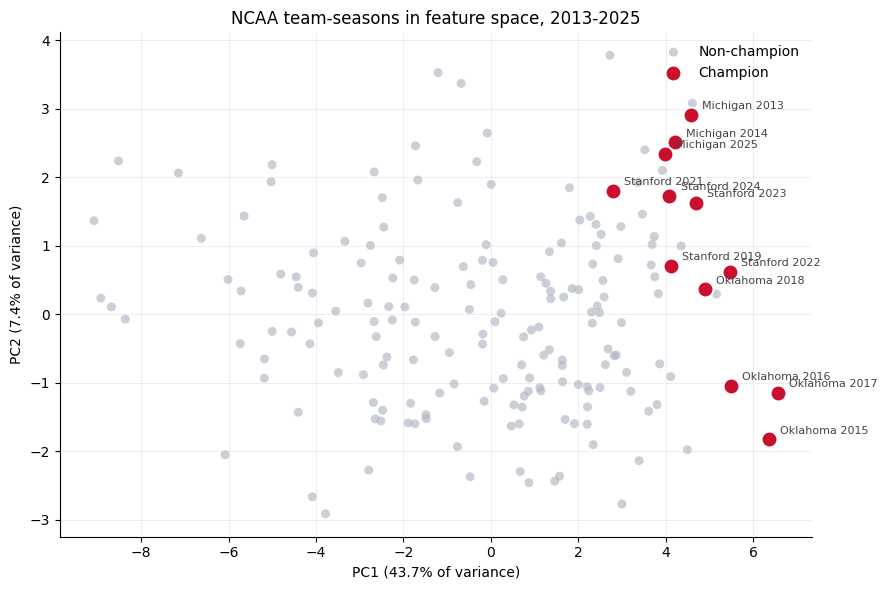

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(df_norm[feature_cols])
is_champ = df_norm['champion'].values == 1

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_2d[~is_champ, 0], X_2d[~is_champ, 1],
           c='#b0b7c3', alpha=0.65, s=42, label='Non-champion', edgecolor='none')
ax.scatter(X_2d[is_champ, 0], X_2d[is_champ, 1],
           c='#c8102e', s=130, label='Champion', edgecolor='white', linewidth=1.4, zorder=3)

for (x, y), (_, row) in zip(X_2d[is_champ], df_norm[is_champ].iterrows()):
    ax.annotate(f"{row['team']} {int(row['year'])}", (x, y),
                textcoords="offset points", xytext=(8, 4), fontsize=8, color='#444')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} of variance)")
ax.set_title("NCAA team-seasons in feature space, 2013-2025")
ax.legend(frameon=False)
ax.grid(alpha=0.25, linewidth=0.6)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## 14. The 2026 Forward Test

Everything so far is retrospective. This section is the only genuinely out-of-sample evidence in the
project: the model was trained on all 12 labeled seasons, then used to predict a championship that
**had not yet been contested**.

The procedure:

1. Fetch 2026 regular-season data, applying the same April 8 cutoff so only pre-championship meets
   are used.
2. Z-score within the 2026 season alone. This is exactly why era normalization was built the way it
   was in Section 7.
3. Score with a model retrained on all of 2013-2025.
4. *Then* reveal the actual result.

In [18]:
# Step 1: fetch 2026, pre-cutoff meets only
raw_2026 = []
for team_id in ALL_TEAM_IDS:
    try:
        dash = requests.get(f"{BASE_URL}/dashboard/2026/{team_id}",
                            headers=HEADERS, timeout=30).json()
        ty   = dash.get('ty_info')
        conf = str(ty.get('conference_id', '')) if isinstance(ty, dict) else ''
        if conf not in NCAA_CONFS:
            continue
        meet_scores = [float(m['team_score']) for m in dash['meets']
                       if m['team_score'] is not None]
        if not meet_scores:
            continue
        cons = requests.get(f"{BASE_URL}/teamconsistency/2026/{team_id}",
                            headers=HEADERS, timeout=30).json()
        raw_2026.append({
            'year': 2026, 'team_id': team_id, 'team_name': dash['info']['team_name'],
            'champion': 0,                       # unknown at prediction time
            'meet_scores': meet_scores, 'meet_dates': cons['labels'],
            'apparatus': {a: [float(x) for x in cons[a]]
                          for a in ['fxs', 'phs', 'srs', 'vts', 'pbs', 'hbs']},
        })
    except Exception:
        pass

rows_2026 = []
for record in raw_2026:
    feats = compute_features(record)
    if feats is None:
        continue
    feats['year'], feats['team'], feats['champion'] = 2026, record['team_name'], 0
    rows_2026.append(feats)

df_2026 = pd.DataFrame(rows_2026)
df_2026 = df_2026[META + [c for c in df_2026.columns if c not in META]]

# Step 2: z-score within 2026 only
df_2026_norm = df_2026.copy()
for col in [c for c in df_2026.columns if c not in META]:
    df_2026_norm[col] = (df_2026[col] - df_2026[col].mean()) / df_2026[col].std()

print(f"2026 teams with enough pre-cutoff meets: {len(df_2026)}")
print(f"Meets used per team: {df_2026['n_meets'].min()}-{df_2026['n_meets'].max()}")

2026 teams with enough pre-cutoff meets: 15
Meets used per team: 6-10


In [19]:
# Step 3: retrain on all 12 labeled seasons, then predict 2026
model_final = LogisticRegression(C=0.1, class_weight='balanced',
                                 max_iter=1000, solver='lbfgs', random_state=42)
model_final.fit(df_norm[feature_cols], df_norm['champion'])
print(f"Trained on {len(df_norm)} team-seasons, "
      f"{int(df_norm['champion'].sum())} champions, {len(feature_cols)} features\n")

pred_2026 = df_2026_norm[['team']].copy()
pred_2026['prob_champion'] = model_final.predict_proba(df_2026_norm[feature_cols])[:, 1]
pred_2026 = pred_2026.sort_values('prob_champion', ascending=False).reset_index(drop=True)
pred_2026.index += 1

print("PREDICTION, made from pre-championship data\n")
print(pred_2026.to_string(float_format=lambda v: f"{v:.4f}"))

print(f"\nSingle-feature baseline (highest nqa_pb): "
      f"{df_2026.loc[df_2026['nqa_pb'].idxmax(), 'team']}")

Trained on 184 team-seasons, 12 champions, 27 features

PREDICTION, made from pre-championship data

                   team  prob_champion
1              Oklahoma         0.8583
2              Stanford         0.8233
3              Michigan         0.6589
4              Nebraska         0.2462
5            Ohio State         0.0979
6            California         0.0298
7              Illinois         0.0119
8            Penn State         0.0091
9            Greenville         0.0065
10                 Navy         0.0008
11                 Army         0.0004
12  Springfield College         0.0002
13            Air Force         0.0001
14       William & Mary         0.0001
15              Simpson         0.0000

Single-feature baseline (highest nqa_pb): Stanford


In [20]:
# Step 4: the actual result
final_2026 = requests.get(f"{BASE_URL}/finalresults/2026",
                          headers=HEADERS, timeout=30).json()['data']

actual = pd.DataFrame([{'team': r['team_name'], 'final_score': float(r['ncaa_final'])}
                       for r in final_2026 if r.get('ncaa_final') is not None])
actual.index = range(1, len(actual) + 1)

print("ACTUAL 2026 NCAA Championship result\n")
print(actual.head(6).to_string(float_format=lambda v: f"{v:.3f}"))

# Side-by-side comparison of the top four
print("\n\nPredicted vs actual, top 4\n")
print(f"{'':>4}  {'PREDICTED':<24}{'ACTUAL':<24}")
for i in range(1, 5):
    p = f"{pred_2026.loc[i, 'team']} ({pred_2026.loc[i, 'prob_champion']:.3f})"
    a = f"{actual.loc[i, 'team']} ({actual.loc[i, 'final_score']:.3f})"
    print(f"{i:>4}. {p:<24}{a:<24}")

margin = actual.loc[1, 'final_score'] - actual.loc[2, 'final_score']
print(f"\nWinning margin: {margin:.3f} points")

ACTUAL 2026 NCAA Championship result

         team  final_score
1    Stanford      329.825
2    Oklahoma      328.495
3    Michigan      324.857
4    Nebraska      324.662
5    Illinois      322.224
6  Ohio State      316.093


Predicted vs actual, top 4

      PREDICTED               ACTUAL                  
   1. Oklahoma (0.858)        Stanford (329.825)      
   2. Stanford (0.823)        Oklahoma (328.495)      
   3. Michigan (0.659)        Michigan (324.857)      
   4. Nebraska (0.246)        Nebraska (324.662)      

Winning margin: 1.330 points


### Reading the forward test

The model picked all four teams that would finish in the top four, and got 3rd and 4th in the right
order. It ranked Oklahoma first and Stanford second. Stanford won by 1.33 points out of roughly 330.

We are not going to call that a miss, and we are not going to call it a hit either. Across the
versions we trained, the top spot moved between Stanford and Oklahoma depending on which features
were in. A 0.4% margin is not a gap the model is equipped to resolve, and the honest read is that it
narrowed the field to the right four teams and then ran out of resolution.

The top-four result deserves a caveat too. Michigan, Oklahoma, and Stanford have won every title
since 2013, and the contender group barely changes year to year. Identifying it is a lower bar than
it sounds like.

What is worth noting is that the single-feature `nqa_pb` rule said Stanford, which takes it to
13/13.

### Why they disagreed: binary ranking vs. continuous features

This gap is another interesting finding of the project.

The `nqa_pb` baseline is a **ranking** rule. It only asks who leads, and Stanford led parallel bars
(54.950 to Oklahoma's 54.775). The logistic regression works in **continuous** values, so that
0.175-point edge was a small nudge, and Oklahoma outweighed it by being marginally stronger across
the rest of its profile.

Neither approach is wrong in general. But it does mean the model's extra features diluted the one
signal that mattered most, and with 12 positive examples there is not enough data for it to learn
how much to trust its own best feature.

## 15. When Does the Model Know?

April 8 was chosen because it maximizes information. But how early does the picture stabilize?

Re-running the entire pipeline at successively later cutoffs answers that. Features that require a
conference championship (`nqa_*`, `conf_champ_total`) are excluded here, since they do not exist
until the season is nearly over.

In [31]:
# Refit at successively later cutoffs
weekly_features = [c for c in feature_cols if not c.startswith('nqa_')]
cutoffs = [((1, 15), 'Jan 15'), ((2, 1), 'Feb 1'), ((2, 15), 'Feb 15'), ((3, 1), 'Mar 1'),
           ((3, 15), 'Mar 15'), ((4, 1), 'Apr 1'), ((4, 8), 'Apr 8')]

track  = ['Stanford', 'Oklahoma', 'Michigan', 'Nebraska']
colors = {'Stanford': '#8C1515', 'Oklahoma': '#841617',
          'Michigan': '#00274C', 'Nebraska': '#E41C38'}
styles = {'Stanford': '-', 'Oklahoma': '--', 'Michigan': '-', 'Nebraska': '--'}

def build(records, cm, cd, year_of=None):
    out = []
    for rec in records:
        f = compute_features(rec, cutoff_month=cm, cutoff_day=cd, min_meets=2)
        if f is None:
            continue
        f['year']     = year_of or rec['year']
        f['team']     = rec['team_name']
        f['champion'] = rec.get('champion', 0)
        out.append(f)
    return pd.DataFrame(out)

def zscore(frame, cols, by_season=True):
    z = frame.copy()
    for c in cols:
        if by_season:
            mu = frame.groupby('year')[c].transform('mean')
            sd = frame.groupby('year')[c].transform('std').replace(0, 1)
        else:
            mu, sd = frame[c].mean(), (frame[c].std() or 1)
        z[c] = (frame[c] - mu) / sd
    return z

by_cutoff = []
for (cm, cd), label in cutoffs:
    hist = build(raw_data, cm, cd)
    if hist.empty:
        continue
    cols = [c for c in weekly_features if c in hist.columns]
    hz   = zscore(hist, cols)

    tr = hz[hz['year'] <= 2023]
    if tr['champion'].sum() == 0:
        print(f"{label}: skipped, no champions have enough meets yet")
        continue

    m = LogisticRegression(C=0.1, class_weight='balanced',
                           max_iter=1000, solver='lbfgs', random_state=42)
    m.fit(tr[cols], tr['champion'])

    entry = {'cutoff': label}
    te = hz[hz['year'] >= 2024].reset_index(drop=True)
    te['prob'] = m.predict_proba(te[cols])[:, 1]
    for yr in (2024, 2025):
        sub = te[te['year'] == yr]
        if sub.empty:
            continue
        champ = sub.loc[sub['champion'] == 1, 'team'].iloc[0]
        entry[f'{yr}_correct'] = sub.loc[sub['prob'].idxmax(), 'team'] == champ
        for t in track:
            row = sub[sub['team'] == t]
            if not row.empty:
                entry[f'{yr}_{t}'] = row['prob'].values[0]

    fut = build(raw_2026, cm, cd, year_of=2026)
    if not fut.empty:
        fz = zscore(fut, cols, by_season=False).reset_index(drop=True)
        fz['prob'] = m.predict_proba(fz[cols])[:, 1]
        for t in track:
            row = fz[fz['team'] == t]
            if not row.empty:
                entry[f'2026_{t}'] = row['prob'].values[0]

    by_cutoff.append(entry)
    print(f"{label}: 2024 {'OK' if entry.get('2024_correct') else 'X '}   "
          f"2025 {'OK' if entry.get('2025_correct') else 'X '}")

Jan 15: skipped, no champions have enough meets yet
Feb 1: 2024 OK   2025 X 
Feb 15: 2024 X    2025 X 
Mar 1: 2024 OK   2025 OK
Mar 15: 2024 OK   2025 OK
Apr 1: 2024 X    2025 X 
Apr 8: 2024 X    2025 X 


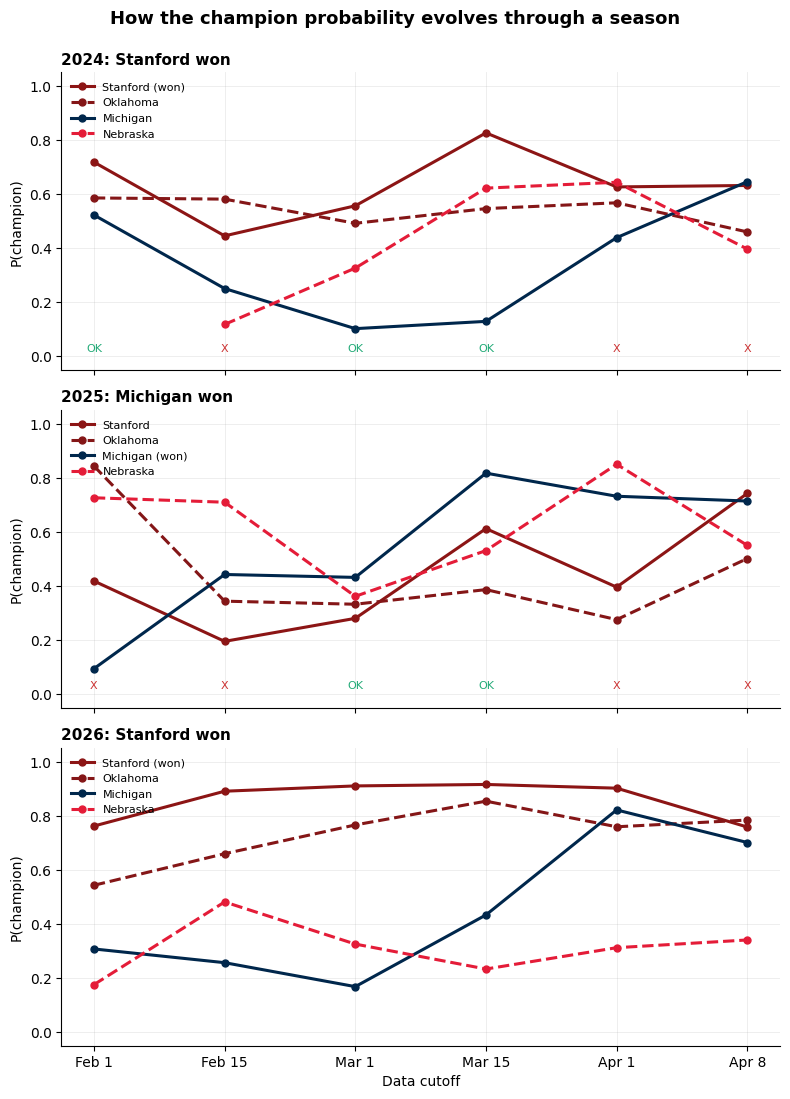

In [32]:
# Plot the trajectories
panels = [(2024, 'Stanford'), (2025, 'Michigan'), (2026, 'Stanford')]
fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)

for ax, (yr, winner) in zip(axes, panels):
    for t in track:
        xs = [e['cutoff'] for e in by_cutoff if f'{yr}_{t}' in e]
        ys = [e[f'{yr}_{t}'] for e in by_cutoff if f'{yr}_{t}' in e]
        if not xs:
            continue
        ax.plot(xs, ys, marker='o', markersize=5, linewidth=2.2,
                linestyle=styles[t], color=colors[t],
                label=t + (" (won)" if t == winner else ""))

    if yr < 2026:
        for e in by_cutoff:
            if f'{yr}_correct' in e:
                ax.annotate('OK' if e[f'{yr}_correct'] else 'X',
                            (e['cutoff'], 0.02), ha='center', fontsize=8,
                            color='#2a7' if e[f'{yr}_correct'] else '#c33')

    ax.set_title(f"{yr}: {winner} won", loc='left', fontsize=11, fontweight='bold')
    ax.set_ylabel("P(champion)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(frameon=False, fontsize=8, loc='upper left')
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

axes[-1].set_xlabel("Data cutoff")
fig.suptitle("How the champion probability evolves through a season",
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

The picture is unstable until roughly **March 1**, and the Apr 1 cutoff is *worse* than Mar 15,
which is a useful warning rather than a bug. Late-season meets are sparse and high-variance, so a
cutoff that lands mid-conference-season catches teams with one or two unrepresentative results. The
value of April 8 is not that later is always better; it is that April 8 sits after conference
championships have resolved, which is what stabilizes the estimate.

With 12 champions total, these trajectories should be read as suggestive, not measured.

## 16. Conclusions and Limitations

### What worked

**Feature engineering mattered more than model selection.** Every gain we got came from building
better inputs, not from fitting better models. Swapping per-event means for per-event NQA moved the
parallel-bars baseline from 10/12 to 12/12. Within-season z-scoring is the only reason a model
trained on 2013 scoring rules can say anything about 2026. Neither needed anything fancier than
logistic regression.

**Parallel bars is where the signal is.** Two independent routes agree on this. The regression put
`nqa_pb` and `max_pb` in its top two weights, and when we followed that hint and tested p-bars
alone, it separated champions better than any whole-team measure we tried.

**The model earned its place as a search tool.** It did not beat the single-feature rule, but we
found the single-feature rule by reading its weights. That is a real contribution even though the
classifier is not the deliverable.

**The data integrity work paid off.** The conference filter that resolved the 6.6% flag rate is the
same filter that keeps GymACT seasons out of the training data.

### What we're less sure about

Everything in the list above came out of a process worth being honest about. The model got 2024 and
2025 right almost immediately, and it was also pretty clearly leaning on Stanford at that point.
From there we changed the regularization, dropped `std_vt`, and swapped means for NQA, and the
output started looking more like something we'd defend.

But looking more defensible is not the same as being measurably better. We were tuning against our
own sense of which rankings seemed reasonable, and against a test set of two seasons that we kept
going back to. The C sweep in Section 12 is scored on those same two held-out seasons, so the test
set had a hand in picking the hyperparameter, and the 2 for 2 result is not as clean as it looks.

With 12 champions total there isn't enough data to separate a real improvement from a story we
fitted to. We think the feature work holds up, mainly because `nqa_pb` survives on seasons it was
never tuned against and on a forward test that hadn't happened yet. We're a lot less confident that
the model tuning did anything beyond moving the output closer to what we already expected.

### What did not work

**The model could not separate the top two.** On 2026 it narrowed the field to the right four teams
and then split hairs between Stanford and Oklahoma, with different versions landing on different
answers. At a 1.33-point margin we do not think any of them constitutes a real call.

### Limitations

1. **The sample is tiny.** 12 labeled seasons, 12 champions, 3 distinct winning programs. The 12/12
   baseline was selected after inspecting these seasons, and would flatter itself on any resample.
   One genuine out-of-sample season (2026) is not enough to settle it.

2. **Three programs win everything.** Michigan, Oklahoma, and Stanford took every title from 2013 to
   2026. A model that learned "be Stanford" would score well, and there is no clean way to rule that
   out from inside this dataset. Extending back to 2013-2015 cut Stanford's share from 5 of 9 to 5
   of 12, and the parallel bars result held up through that (Section 11), but the model itself still
   leans Stanford's way.

3. **`mean_total` may be misaligned.** The season-level totals come from the `dashboard` endpoint
   while the apparatus scores and dates come from `teamconsistency`, and the two do not always
   contain the same number of meets. `compute_features` takes `meet_scores[:len(valid)]`, a
   positional slice that assumes the two lists agree from the start. The apparatus features are
   unaffected, since they index `teamconsistency` directly, but the four `*_total` features should be
   re-derived by joining on date before being trusted.

4. **NQA degrades on teams with very few meets.** The formula takes `sorted_reg[1:4]` and divides
   by 4, so a team-season with fewer than five pre-cutoff meets contributes fewer than three
   regular-season scores to a sum that is still divided by four, deflating its NQA. At the April 8
   cutoff most teams have 8-12 meets so this rarely binds, but it is a latent trap for short seasons
   and for the early cutoffs in Section 15. Worth adding an explicit guard.

5. **The conference championship is inferred, not labeled.** Nothing in the API flags which meet
   was a team's conference championship, so we take the last meet on or before the cutoff. We
   checked the April 8 boundary itself against the meet labels in all 13 seasons and it holds, but
   the inference would break for any team whose last pre-cutoff meet was not their conference meet.

6. **NQA was never checked against RTN's published figures.** The implementation here matches the
   described NCAA procedure and produces sensible results, but it has not been reconciled against
   RTN's own NQA/RQS numbers. The 13/13 agreement with champions is circumstantial support, not
   verification.

7. **No confidence intervals anywhere.** With 12 positive examples, the difference between 10/12 and
   12/12 is one or two seasons, well inside the noise.

### If this continued

- Reconcile the NQA implementation against RTN's published values.
- Re-derive the `*_total` features with a date join instead of a positional slice.
- Test whether p-bars dominance is causal or an artifact of the same programs leading everything,
  for example by checking whether `nqa_pb` still separates champions once overall team strength is
  partialled out.
- Predict the **top four** rather than the winner. The forward test suggests the model is
  meaningfully better at bracketing contenders than at ordering them, and a four-team target would
  have 4x the positive examples.
- Topological data analysis was discussed as a direction and deferred for time.

---

*Data: [Road to Nationals](https://www.roadtonationals.com) men's gymnastics API.
Seasons 2013-2026, 2020 excluded (COVID-19).*